In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch

In [ ]:
df = pd.read_csv(r"C:\Users\shard\OneDrive\Desktop\TOPS\ML\UnSupervised\customer_segmentation.csv")
# Select important features
print(df.columns)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


In [9]:
print(df.isnull().sum)


<bound method DataFrame.sum of          ID  Year_Birth  Education  Marital_Status  Income  Kidhome  Teenhome  \
0     False       False      False           False   False    False     False   
1     False       False      False           False   False    False     False   
2     False       False      False           False   False    False     False   
3     False       False      False           False   False    False     False   
4     False       False      False           False   False    False     False   
...     ...         ...        ...             ...     ...      ...       ...   
2235  False       False      False           False   False    False     False   
2236  False       False      False           False   False    False     False   
2237  False       False      False           False   False    False     False   
2238  False       False      False           False   False    False     False   
2239  False       False      False           False   False    False     False 

In [10]:
X = df[['Income', 'Recency', 'MntWines', 'MntFruits',
        'MntMeatProducts', 'MntFishProducts',
        'MntSweetProducts', 'MntGoldProds']]

# Handle missing values
X = X.dropna()

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


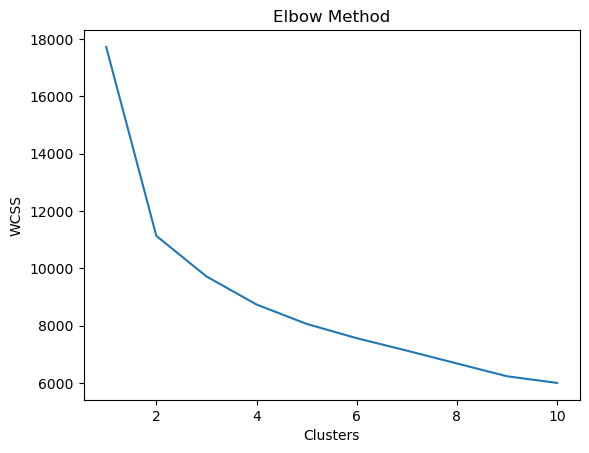

In [13]:
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)


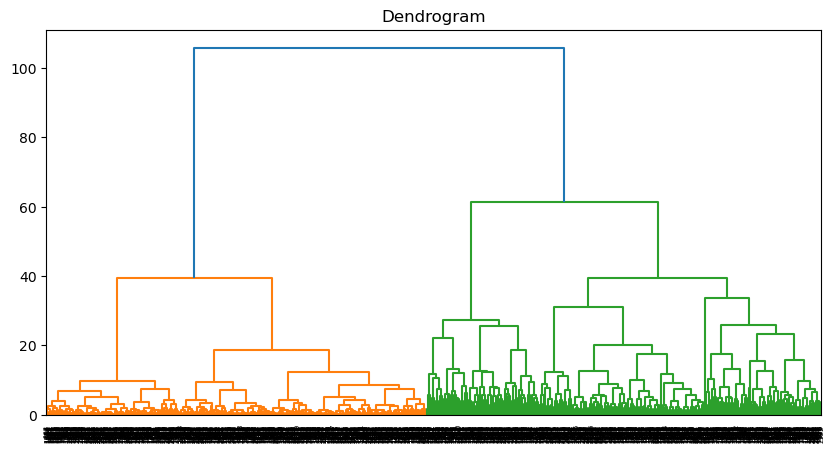

In [15]:
plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.show()

hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_scaled)


In [16]:
df = df.loc[X.index]  # align after dropna
df['KMeans_Cluster'] = kmeans_labels
df['HC_Cluster'] = hc_labels

print(df[['KMeans_Cluster', 'HC_Cluster']].head())

   KMeans_Cluster  HC_Cluster
0               2           2
1               3           0
2               0           1
3               3           0
4               1           3


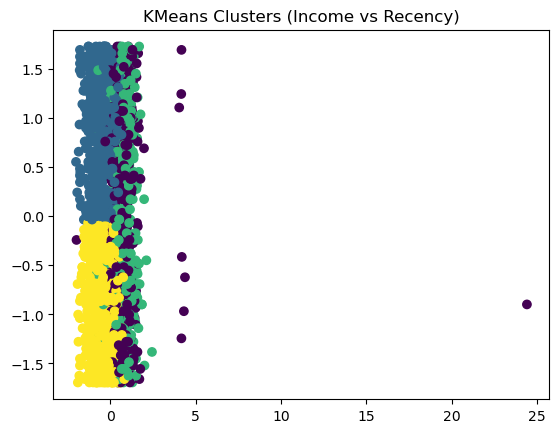

In [17]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("KMeans Clusters (Income vs Recency)")
plt.show()